In [1]:
import sys
print(sys.executable)

C:\Users\KHUSHI RANI\.conda\envs\MyNewEnv\python.exe


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("diabetes_prediction_dataset.csv")

In [4]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [6]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [7]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [8]:
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

df['smoking_history'] = df['smoking_history'].fillna(
    df['smoking_history'].mode()[0]
)

In [9]:
df.drop_duplicates(inplace=True)

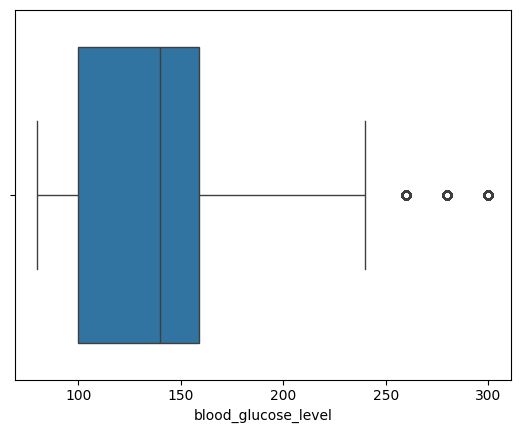

In [10]:
sns.boxplot(x=df['blood_glucose_level'])

plt.show()

In [11]:
Q1 = df['blood_glucose_level'].quantile(0.25)
Q3 = df['blood_glucose_level'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df['blood_glucose_level'] >= lower) &
    (df['blood_glucose_level'] <= upper)
]

In [12]:
df['RiskScore'] = (
    df['hypertension'] +
    df['heart_disease']
)

In [13]:
df['BMI_Category'] = pd.cut(
    df['bmi'],
    bins=[0,18.5,25,30,100],
    labels=[
        'Underweight',
        'Normal',
        'Overweight',
        'Obese'
    ]
)

In [14]:
df['SugarRisk'] = (
    df['blood_glucose_level'] *
    df['HbA1c_level']
)

In [15]:
df = pd.get_dummies(
    df,
    columns=[
        'gender',
        'smoking_history',
        'BMI_Category'
    ]
)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

columns = [
    'age',
    'bmi',
    'HbA1c_level',
    'blood_glucose_level'
]

df[columns] = scaler.fit_transform(df[columns])

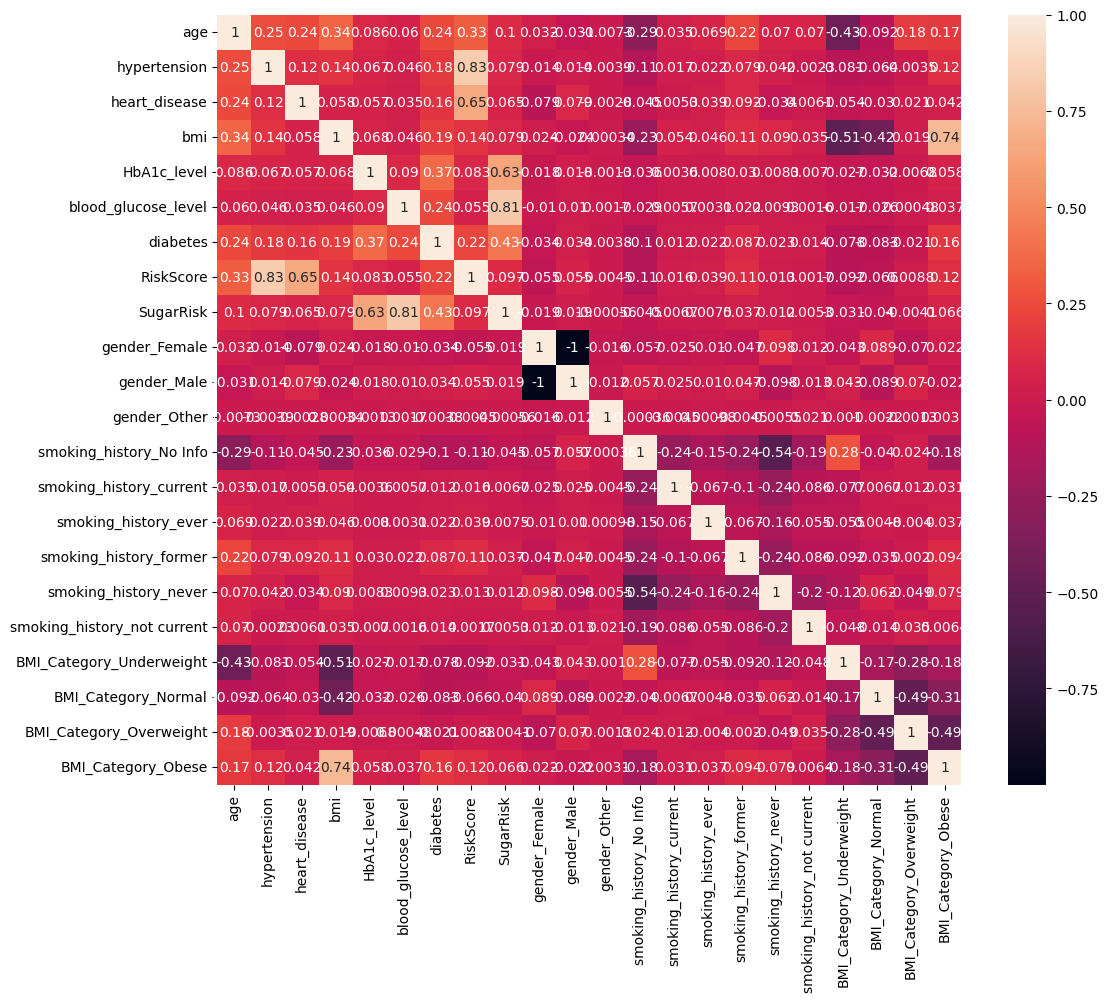

In [17]:
plt.figure(figsize=(12,10))

sns.heatmap(df.corr(), annot=True)

plt.show()

In [18]:
print(df.dtypes)

age                            float64
hypertension                     int64
heart_disease                    int64
bmi                            float64
HbA1c_level                    float64
blood_glucose_level            float64
diabetes                         int64
RiskScore                        int64
SugarRisk                      float64
gender_Female                     bool
gender_Male                       bool
gender_Other                      bool
smoking_history_No Info           bool
smoking_history_current           bool
smoking_history_ever              bool
smoking_history_former            bool
smoking_history_never             bool
smoking_history_not current       bool
BMI_Category_Underweight          bool
BMI_Category_Normal               bool
BMI_Category_Overweight           bool
BMI_Category_Obese                bool
dtype: object


In [19]:
df = pd.get_dummies(df, drop_first=True)

In [20]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

In [21]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

rfe = RFE(model, n_features_to_select=5)

X_rfe = rfe.fit_transform(X, y)

In [22]:
selected_features = X.columns[rfe.support_]

print(selected_features)

Index(['age', 'HbA1c_level', 'gender_Female', 'gender_Male',
       'BMI_Category_Underweight'],
      dtype='object')


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

In [25]:
from sklearn.feature_selection import RFE

rfe = RFE(model, n_features_to_select=5)

X_rfe = rfe.fit_transform(X_scaled, y)

In [26]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Features and target
X = df.drop('diabetes', axis=1)
y = df['diabetes']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Logistic Regression model
model = LogisticRegression(max_iter=5000)

# RFE
rfe = RFE(model, n_features_to_select=5)

# Fit RFE
X_rfe = rfe.fit_transform(X_scaled, y)

# Selected features
selected_features = X.columns[rfe.support_]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['age', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'SugarRisk'], dtype='object')


In [27]:
X = df.drop('diabetes', axis=1)

y = df['diabetes']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

In [30]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [31]:
predictions = model.predict(X_test)

In [32]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.9596238644211869
